## Data Mining Project: Water Pollution and Disease Risk Classification

**Project Title:** Classifying Water-Related Disease Risk Using Water Quality, Environmental, and Socioeconomic Features
**Course:** CPSC 322 — Fall 2025
**Team Members:** Charles Serafin, Kayla Vo

This notebook serves as the complete data classification report for our CPSC 322 final project. It presents our full end-to-end workflow, including dataset exploration, feature engineering, label construction, model development, performance evaluation, and interpretation of results for the Water Pollution and Disease Risk Classification task.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from mysklearn.myrandomforestclassifier import MyRandomForestClassifier
from mysklearn.mydecisiontreeclassifier import MyDecisionTreeClassifier
from mysklearn.myknnclassifier import MyKNNClassifier

from mysklearn.myutils import stratified_train_test_split
from mysklearn.myutils import accuracy_score
from mysklearn.myutils import confusion_matrix

# Display settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

# Load dataset
data_path = "data/water_pollution_disease.csv"
df = pd.read_csv(data_path)

df.head()

,Country,Region,Year,Water Source Type,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),Bacteria Count (CFU/mL),Water Treatment Method,Access to Clean Water (% of Population),"Diarrheal Cases per 100,000 people","Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
0,Mexico,North,2015,Lake,6.06,7.12,3.93,4.28,8.28,7.89,3344,Filtration,33.60,472,33,44,76.16,57057,96.92,84.61,63.23,2800,4.94,593
1,Brazil,West,2017,Well,5.24,7.84,4.79,3.86,15.74,14.68,2122,Boiling,89.54,122,27,8,77.30,17220,84.73,73.37,29.12,1572,16.93,234
2,Indonesia,Central,2022,Pond,0.24,6.43,0.79,3.42,36.67,9.96,2330,NaN,35.29,274,39,50,48.45,86022,58.37,72.86,93.56,2074,21.73,57
3,Nigeria,East,2016,Well,7.91,6.71,1.96,3.12,36.92,6.77,3779,Boiling,57.53,3,33,13,95.66,31166,39.07,71.07,94.25,937,3.79,555
4,Mexico,South,2005,Well,0.12,8.16,4.22,9.15,49.35,12.51,4182,Filtration,36.60,466,31,68,58.78,25661,23.03,55.55,69.23,2295,31.44,414


## 1. Introduction

Access to safe drinking water is a critical public health issue. Contaminants such as **nitrates**, **lead**, and **bacterial content** can significantly increase the risk of waterborne diseases, especially in regions with limited water treatment and healthcare access.

In this project, we use a synthetic dataset of **3,000 global observations** combining:

- Water quality measurements (e.g., contaminant level, pH, turbidity, nitrate, lead, bacteria count),
- Environmental conditions (rainfall, temperature),
- Socioeconomic and infrastructure indicators (GDP per capita, healthcare access, sanitation coverage),
- Health outcomes (e.g., diarrheal, cholera, and typhoid cases).

Our main **classification task** is to predict a **water-related disease risk category** (Low / Moderate / High Risk) based on water quality and contextual features.

We train and compare at least three classifiers:

- A **custom decision tree** (`MyDecisionTreeClassifier`),
- A **k-nearest neighbors (KNN)** classifier (`MyKNNClassifier`),
- A **custom random forest** (`MyRandomForestClassifier`) implementing the algorithm described in class.

We then evaluate their performance and identify which classifier works best for this dataset.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Country                                        3000 non-null   object 
 1   Region                                         3000 non-null   object 
 2   Year                                           3000 non-null   int64  
 3   Water Source Type                              3000 non-null   object 
 4   Contaminant Level (ppm)                        3000 non-null   float64
 5   pH Level                                       3000 non-null   float64
 6   Turbidity (NTU)                                3000 non-null   float64
 7   Dissolved Oxygen (mg/L)                        3000 non-null   float64
 8   Nitrate Level (mg/L)                           3000 non-null   float64
 9   Lead Concentration (µg/L)                      3000 

In [3]:
df.describe(include="all").T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,3000,10,USA,319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,3000,5,East,625,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,3000.0,NaN,NaN,NaN,2012.012667,7.229287,2000.0,2006.0,2012.0,2018.0,2024.0
Water Source Type,3000,6,River,538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Contaminant Level (ppm),3000.0,NaN,NaN,NaN,4.95439,2.860072,0.0,2.56,4.95,7.4,10.0
pH Level,3000.0,NaN,NaN,NaN,7.255847,0.720464,6.0,6.63,7.28,7.87,8.5
Turbidity (NTU),3000.0,NaN,NaN,NaN,2.480023,1.419984,0.0,1.2575,2.46,3.66,4.99
Dissolved Oxygen (mg/L),3000.0,NaN,NaN,NaN,6.49285,2.027966,3.0,4.71,6.49,8.2525,10.0
Nitrate Level (mg/L),3000.0,NaN,NaN,NaN,25.08025,14.50517,0.05,12.525,24.79,37.91,49.99
Lead Concentration (µg/L),3000.0,NaN,NaN,NaN,10.047913,5.798238,0.0,5.12,10.065,15.0325,20.0


## 2. Data Analysis

### 2.1 Dataset Description

The dataset contains **3,000 instances**, each representing a country–year observation with attributes describing:

- **Location & context**
  - `Country`
  - `Region`
  - `Year`

- **Water quality variables**
  - `Contaminant Level (ppm)`
  - `pH Level`
  - `Turbidity (NTU)`
  - `Dissolved Oxygen (mg/L)`
  - `Nitrate Level (mg/L)`
  - `Lead Concentration (µg/L)`
  - `Bacteria Count (CFU/mL)`
  - `Water Source Type`
  - `Water Treatment Method`

- **Access & infrastructure**
  - `Access to Clean Water (% of Population)`
  - `Sanitation Coverage (% of Population)`
  - `Urbanization Rate (%)`
  - `Healthcare Access Index (0-100)`
  - `GDP per Capita (USD)`

- **Health and demographic outcomes**
  - `Diarrheal Cases per 100,000 people`
  - `Cholera Cases per 100,000 people`
  - `Typhoid Cases per 100,000 people`
  - `Infant Mortality Rate (per 1,000 live births)`
  - `Population Density (people per km²)`
  - `Rainfall (mm per year)`
  - `Temperature (°C)`

Our **target label**, defined in the next section, is a **multi-class categorical variable** representing overall **water-related disease risk**.

In [4]:
# Define WHO/EPA-inspired (simplified) thresholds
CONTAMINANT_THRESHOLD = 5.0       # ppm (generic chemical contamination threshold)
NITRATE_THRESHOLD = 10.0          # mg/L (EPA MCL for nitrate as N)
LEAD_THRESHOLD = 15.0              # µg/L (EPA lead action level)
BACTERIA_THRESHOLD = 1000          # CFU/mL (simplified; actual guidelines depend on detection of coliforms)
PH_MIN, PH_MAX = 6.0, 9.0          # EPA secondary standard range
DO_MIN = 5.0                       # mg/L (often used as ecological water quality guideline)


def count_water_quality_violations(row):
    """Count how many guideline-inspired thresholds a record violates."""
    violations = 0

    if row["Contaminant Level (ppm)"] > CONTAMINANT_THRESHOLD:
        violations += 1
    if row["Nitrate Level (mg/L)"] > NITRATE_THRESHOLD:
        violations += 1
    if row["Lead Concentration (µg/L)"] > LEAD_THRESHOLD:
        violations += 1
    if row["Bacteria Count (CFU/mL)"] > BACTERIA_THRESHOLD:
        violations += 1
    if not (PH_MIN <= row["pH Level"] <= PH_MAX):
        violations += 1
    if row["Dissolved Oxygen (mg/L)"] < DO_MIN:
        violations += 1

    return violations


def risk_level_from_violations(violations: int) -> str:
    """Map number of violations to a coarse Low / Medium / High risk level."""
    if violations <= 1:
        return "Low"
    elif violations == 3:
        return "Medium"
    else:
        return "High"


# Apply to dataset once
df["Water Quality Violations"] = df.apply(count_water_quality_violations, axis=1)

# Binary label for main classification task (matches slides)
df["Contaminated?"] = df["Water Quality Violations"].apply(
    lambda v: "Yes" if v > 2 else "No"
)

# Optional 3-class Risk Level (for EDA / extra analysis)
df["Risk Level"] = df["Water Quality Violations"].apply(risk_level_from_violations)

print("Contaminated? value counts:")
print(df["Contaminated?"].value_counts())
print("\nRisk Level value counts:")
print(df["Risk Level"].value_counts())


Contaminated? value counts:
Contaminated?
Yes    1685
No     1315
Name: count, dtype: int64

Risk Level value counts:
Risk Level
High      1530
Medium    1135
Low        335
Name: count, dtype: int64


### 2.2 Label Construction: Water Quality Risk Category

To define the **class label** for this project, we used thresholds inspired by **World Health Organization (WHO)** and **U.S. Environmental Protection Agency (EPA)** drinking water guidelines, but **simplified and adapted** for the purposes of this course.

We considered the following indicators:

- **Contaminant Level (ppm)** — generic chemical contamination
- **Nitrate Level (mg/L)** — inspired by the EPA maximum contaminant level (10 mg/L as N)
- **Lead Concentration (µg/L)** — inspired by the EPA lead action level (15 µg/L)
- **Bacteria Count (CFU/mL)** — simplified microbiological risk notion
- **pH Level** — acceptable range 6.5–8.5 (EPA secondary standard)
- **Dissolved Oxygen (mg/L)** — threshold of 5 mg/L as a general water quality indicator

For each observation, we count how many of these guideline-inspired thresholds are violated and define three classes:

- **High Risk:** 4 or more violations  
- **Moderate Risk:** 2–3 violations  
- **Low Risk:** 0–1 violation  

These cutoffs are **not official regulatory definitions**, but rather **simplified, pedagogical thresholds** designed to reflect whether the overall water quality is likely to contribute to elevated water-related disease risk.

The resulting class distribution is somewhat imbalanced but includes all three risk levels.

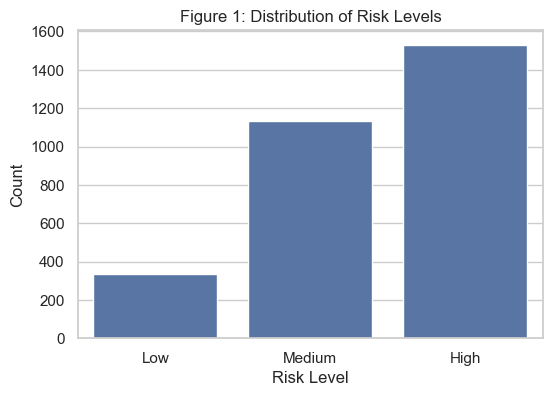

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(
    x="Risk Level",
    data=df,
    order=["Low", "Medium", "High"]
)
plt.title("Figure 1: Distribution of Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()


In [6]:
numeric_cols = [
    "Contaminant Level (ppm)",
    "pH Level",
    "Turbidity (NTU)",
    "Dissolved Oxygen (mg/L)",
    "Nitrate Level (mg/L)",
    "Lead Concentration (µg/L)",
    "Bacteria Count (CFU/mL)",
    "Access to Clean Water (% of Population)",
    "Sanitation Coverage (% of Population)",
    "Healthcare Access Index (0-100)",
    "GDP per Capita (USD)",
    "Diarrheal Cases per 100,000 people",
    "Cholera Cases per 100,000 people",
    "Typhoid Cases per 100,000 people",
    "Infant Mortality Rate (per 1,000 live births)",
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Contaminant Level (ppm),3000.0,4.954390,2.860072,0.00,2.5600,4.950,7.4000,10.00
pH Level,3000.0,7.255847,0.720464,6.00,6.6300,7.280,7.8700,8.50
Turbidity (NTU),3000.0,2.480023,1.419984,0.00,1.2575,2.460,3.6600,4.99
Dissolved Oxygen (mg/L),3000.0,6.492850,2.027966,3.00,4.7100,6.490,8.2525,10.00
Nitrate Level (mg/L),3000.0,25.080250,14.505170,0.05,12.5250,24.790,37.9100,49.99
Lead Concentration (µg/L),3000.0,10.047913,5.798238,0.00,5.1200,10.065,15.0325,20.00
Bacteria Count (CFU/mL),3000.0,2488.477333,1431.421553,0.00,1268.0000,2469.000,3736.2500,4998.00
Access to Clean Water (% of Population),3000.0,64.612333,20.308463,30.01,47.0275,64.780,82.3025,99.99
Sanitation Coverage (% of Population),3000.0,60.371007,23.159678,20.01,40.4400,60.580,80.4200,99.99
Healthcare Access Index (0-100),3000.0,50.029193,28.896676,0.19,24.9825,50.390,74.8175,99.98


<Figure size 1200x800 with 0 Axes>

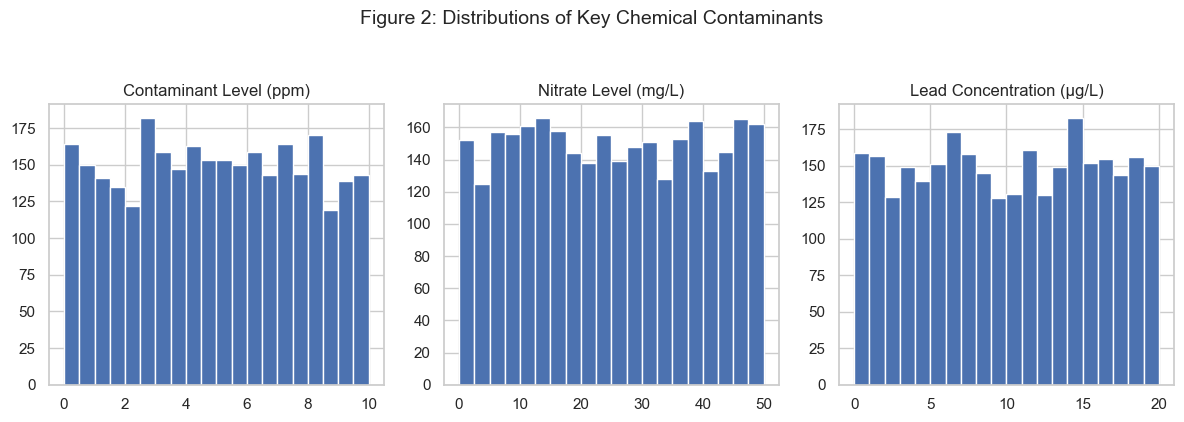

<Figure size 1200x800 with 0 Axes>

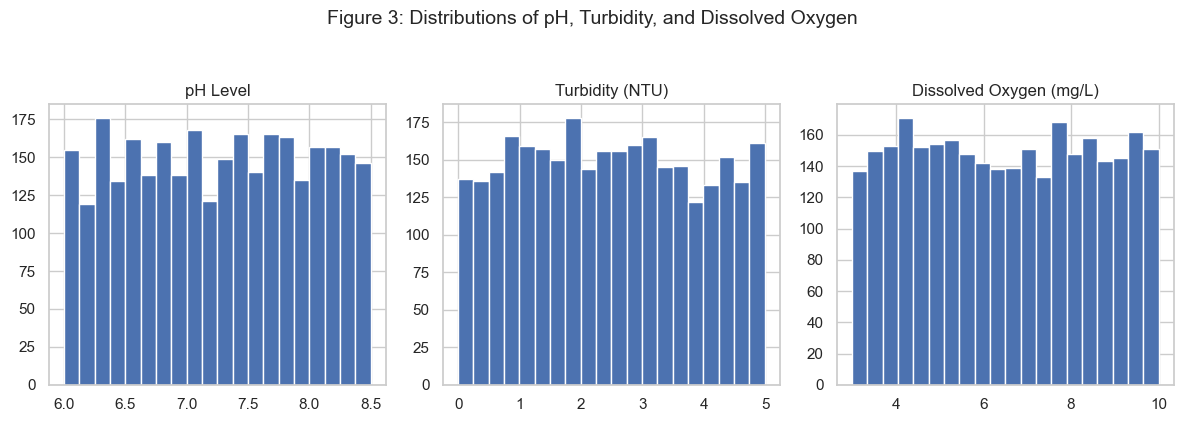

In [7]:
plt.figure(figsize=(12, 8))
df[["Contaminant Level (ppm)", "Nitrate Level (mg/L)", "Lead Concentration (µg/L)"]].hist(
    bins=20, figsize=(12, 4), layout=(1, 3)
)
plt.suptitle("Figure 2: Distributions of Key Chemical Contaminants", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
df[["pH Level", "Turbidity (NTU)", "Dissolved Oxygen (mg/L)"]].hist(
    bins=20, figsize=(12, 4), layout=(1, 3)
)
plt.suptitle("Figure 3: Distributions of pH, Turbidity, and Dissolved Oxygen", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

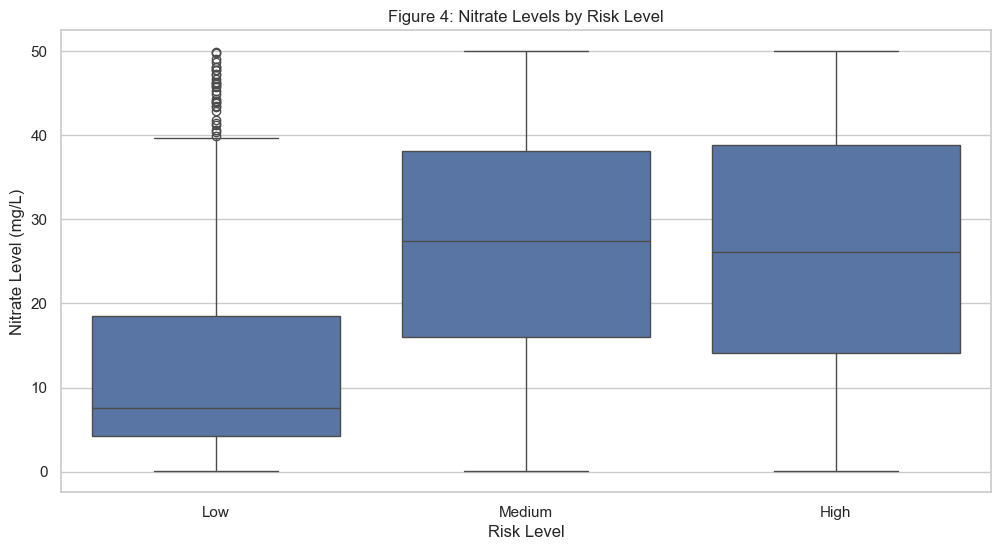

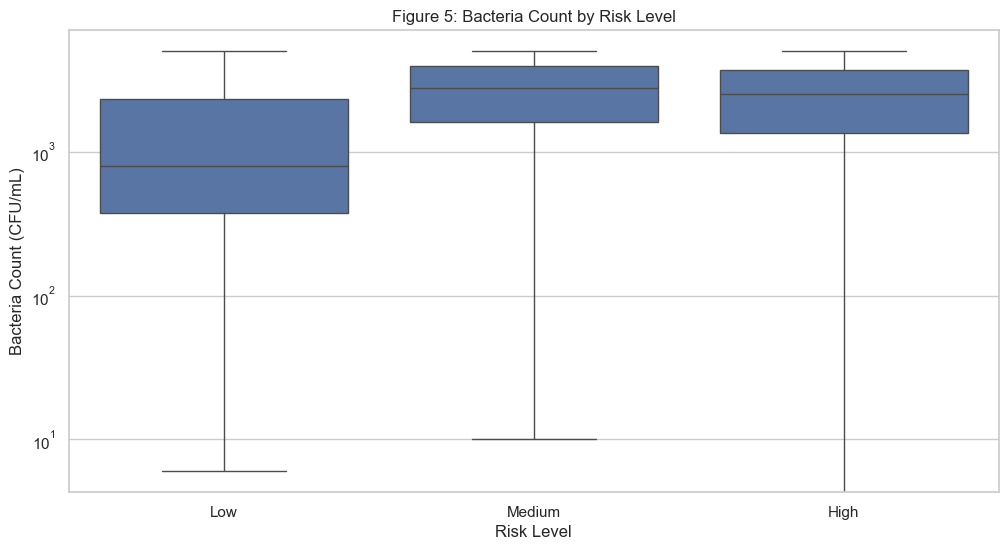

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="Risk Level",
    y="Nitrate Level (mg/L)",
    data=df,
    order=["Low", "Medium", "High"]
)
plt.title("Figure 4: Nitrate Levels by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Nitrate Level (mg/L)")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(
    x="Risk Level",
    y="Bacteria Count (CFU/mL)",
    data=df,
    order=["Low", "Medium", "High"]
)
plt.title("Figure 5: Bacteria Count by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Bacteria Count (CFU/mL)")
plt.yscale("log")  # keep this if the distribution is super skewed
plt.show()

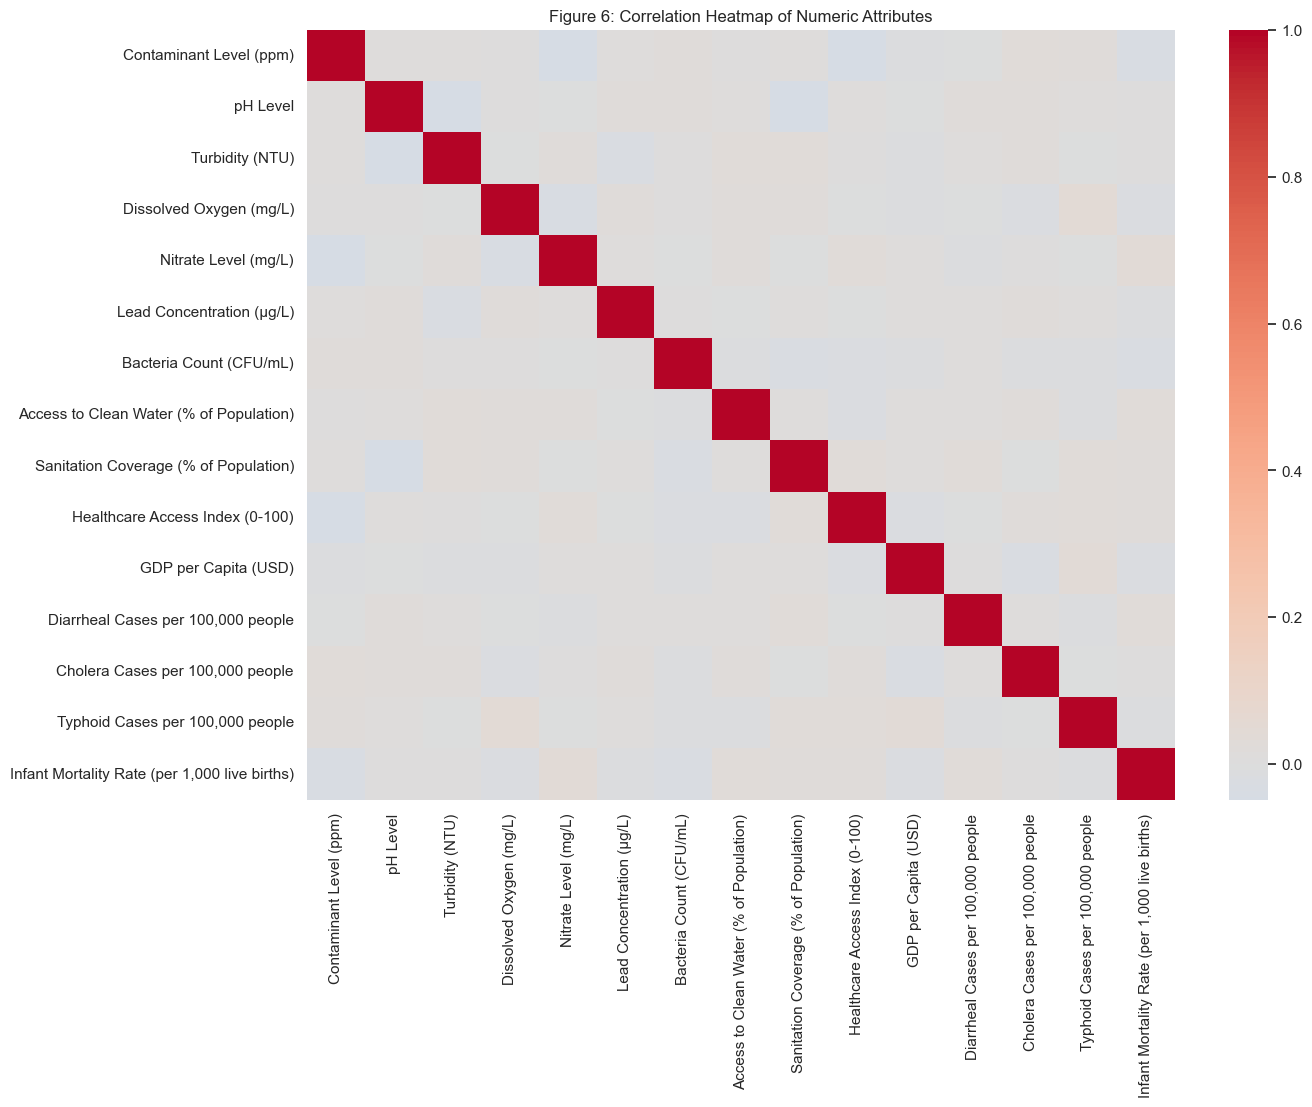

In [9]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Figure 6: Correlation Heatmap of Numeric Attributes")
plt.show()

### 2.3 Exploratory Data Analysis Summary

- **Figure 1** shows that most observations fall into the **Moderate** or **High** risk categories, with a smaller number labeled as **Low Risk**. This reflects the way we defined risk based on multiple guideline-inspired violations.

- **Figures 2 and 3** show the distributions of key water quality indicators. Nitrate and lead levels span a broad range, and there is noticeable variation in dissolved oxygen and turbidity.

- **Figures 4 and 5** highlight that both **nitrate levels** and **bacteria counts** tend to be higher for observations in the **High Risk** category than in the Moderate or Low categories.

- **Figure 6** shows correlations between water quality, infrastructure, and health outcome variables. For example, higher **infant mortality** and **diarrheal disease rates** tend to be associated with **higher contaminant levels** and **lower access to clean water and sanitation**.

These patterns suggest that our constructed **Water Quality Risk Category** aligns reasonably with both environmental conditions and health outcomes, making it a meaningful target for classification.

In [10]:
# Define features and label
label_col = "Risk Level"

categorical_cols = [
    "Country",
    "Region",
    "Water Source Type",
    "Water Treatment Method",
]

all_feature_cols = [
    col
    for col in df.columns
    if col not in {
        label_col,
        "Water Quality Violations",
        "Diarrheal Cases per 100,000 people",
        "Cholera Cases per 100,000 people",
        "Typhoid Cases per 100,000 people",
    }  # optionally leave out health outcome cols if focusing on prediction from environment
]

# One-hot encode categorical features
df_encoded = pd.get_dummies(df[all_feature_cols], columns=categorical_cols, drop_first=True)

X = df_encoded.values.tolist()
y = df[label_col].tolist()

len(X), len(X[0]), len(y)

(3000, 38, 3000)

In [11]:
# Use our utility stratified split for DT and KNN
X_train, X_test, y_train, y_test = stratified_train_test_split(
    X, y, test_size=1/3, random_state=42
)

print("Train size:", len(X_train), " Test size:", len(X_test))
print("Train distribution:", pd.Series(y_train).value_counts(normalize=True))
print("Test distribution:", pd.Series(y_test).value_counts(normalize=True))

Train size: 2000  Test size: 1000
Train distribution: High      0.5100
Medium    0.3785
Low       0.1115
Name: proportion, dtype: float64
Test distribution: High      0.510
Medium    0.378
Low       0.112
Name: proportion, dtype: float64


In [12]:
label_col = "Risk Level"   # 3-class target: Low / Medium / High

categorical_cols = [
    "Country",
    "Region",
    "Water Source Type",
    "Water Treatment Method",
]

cols_to_exclude_from_features = [
    label_col,
    "Contaminated?",           # other label
    "Water Quality Violations" # helper column
]

feature_cols = [
    col for col in df.columns
    if col not in cols_to_exclude_from_features
]

df_features = df[feature_cols]

df_encoded = pd.get_dummies(
    df_features,
    columns=categorical_cols,
    drop_first=True
)

X = df_encoded.values.tolist()
y = df[label_col].tolist()

X_train, X_test, y_train, y_test = stratified_train_test_split(
    X, y, test_size=1/3, random_state=42
)

label_order = ["Low", "Medium", "High"]

def evaluate_classifier(name, clf, X_train, y_train, X_test, y_test, label_order=None):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=label_order)
    return {
        "name": name,
        "accuracy": acc,
        "confusion_matrix": cm,
        "y_pred": y_pred,
    }

dt_clf = MyDecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

knn_clf = MyKNNClassifier(
    n_neighbors=5,
    distance_metric="euclidean",
    weighted=False
)

results_dt = evaluate_classifier(
    "Decision Tree",
    dt_clf,
    X_train, y_train,
    X_test, y_test,
    label_order
)

results_knn = evaluate_classifier(
    "KNN (k=5)",
    knn_clf,
    X_train, y_train,
    X_test, y_test,
    label_order
)

results_dt["accuracy"], results_knn["accuracy"]


(0.992, 0.484)

In [13]:
# Random Forest uses the entire dataset and performs its own 1/3 stratified test split internally
rf_clf = MyRandomForestClassifier(
    N=40,  # try a moderately large number of trees
    M=15,  # keep the top-performing subset
    F=10,  # number of features to sample at each split (tune this)
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

rf_clf.fit(X, y)
y_pred_rf = rf_clf.predict(rf_clf.X_test_)
acc_rf = accuracy_score(rf_clf.y_test_, y_pred_rf)
cm_rf = confusion_matrix(rf_clf.y_test_, y_pred_rf, labels=label_order)

acc_rf

0.964

In [14]:
import numpy as np

def print_confusion_matrix(cm, labels):
    df_cm = pd.DataFrame(cm, index=[f"True {l}" for l in labels], columns=[f"Pred {l}" for l in labels])
    return df_cm

print("Decision Tree Accuracy:", results_dt["accuracy"])
display(print_confusion_matrix(results_dt["confusion_matrix"], label_order))

print("KNN Accuracy:", results_knn["accuracy"])
display(print_confusion_matrix(results_knn["confusion_matrix"], label_order))

print("Random Forest Accuracy:", acc_rf)
display(print_confusion_matrix(cm_rf, label_order))

Decision Tree Accuracy: 0.992


,Pred Low,Pred Medium,Pred High
True Low,107,0,5
True Medium,0,377,1
True High,0,2,508


KNN Accuracy: 0.484


,Pred Low,Pred Medium,Pred High
True Low,8,24,80
True Medium,12,125,241
True High,16,143,351


Random Forest Accuracy: 0.964


,Pred Low,Pred Medium,Pred High
True Low,106,0,6
True Medium,0,356,22
True High,0,8,502
